<a href="https://colab.research.google.com/github/ArnavK04/PH354-Assignments/blob/main/Kumar_Arnav_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question - 1**

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Half-lives (seconds)
tau_Bi = 46 * 60
tau_Tl = 2.2 * 60
tau_Pb = 3.3 * 60

dt = 1

# Decay probabilities per step
p_Bi = 1 - 2**(-dt / tau_Bi)
p_Tl = 1 - 2**(-dt / tau_Tl)
p_Pb = 1 - 2**(-dt / tau_Pb)

# Initial counts
N_Bi = 10000
N_Tl = 0
N_Pb = 0
N_Bi209 = 0

steps = 20000
Bi_arr = []
Tl_arr = []
Pb_arr = []
Bi209_arr = []

for t in range(steps):

    decays_Pb = np.sum(np.random.rand(N_Pb) < p_Pb)
    N_Pb -= decays_Pb
    N_Bi209 += decays_Pb

    decays_Tl = np.sum(np.random.rand(N_Tl) < p_Tl)
    N_Tl -= decays_Tl
    N_Pb += decays_Tl

    decays_Bi = np.sum(np.random.rand(N_Bi) < p_Bi)

    if decays_Bi > 0:
        branch = np.random.rand(decays_Bi)
        to_Pb = np.sum(branch < 0.9791)
        to_Tl = decays_Bi - to_Pb
    else:
        to_Pb = 0
        to_Tl = 0

    N_Bi -= decays_Bi
    N_Pb += to_Pb
    N_Tl += to_Tl

    Bi_arr.append(N_Bi)
    Tl_arr.append(N_Tl)
    Pb_arr.append(N_Pb)
    Bi209_arr.append(N_Bi209)

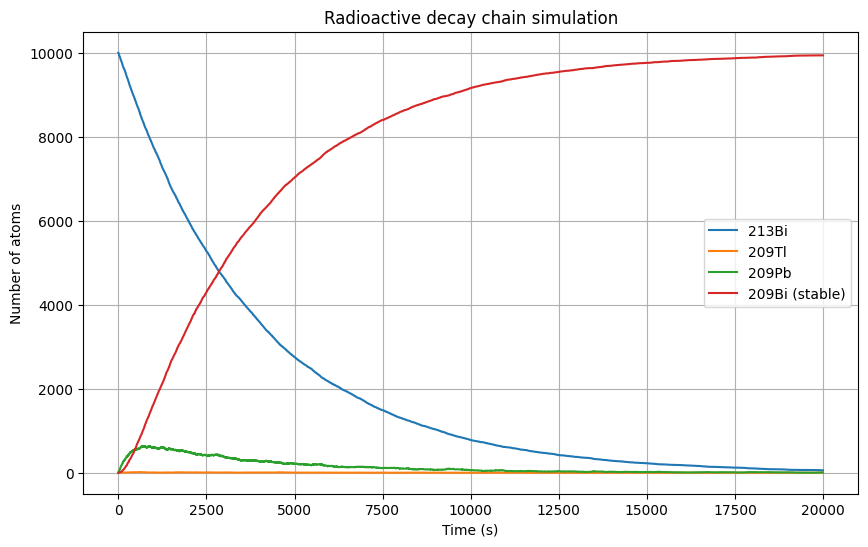

In [54]:
plt.figure(figsize=(10,6))

plt.plot(Bi_arr, label="213Bi")
plt.plot(Tl_arr, label="209Tl")
plt.plot(Pb_arr, label="209Pb")
plt.plot(Bi209_arr, label="209Bi (stable)")

plt.xlabel("Time (s)")
plt.ylabel("Number of atoms")
plt.legend()
plt.grid(which='both')
plt.title("Radioactive decay chain simulation")

plt.show()

# **Question - 2**

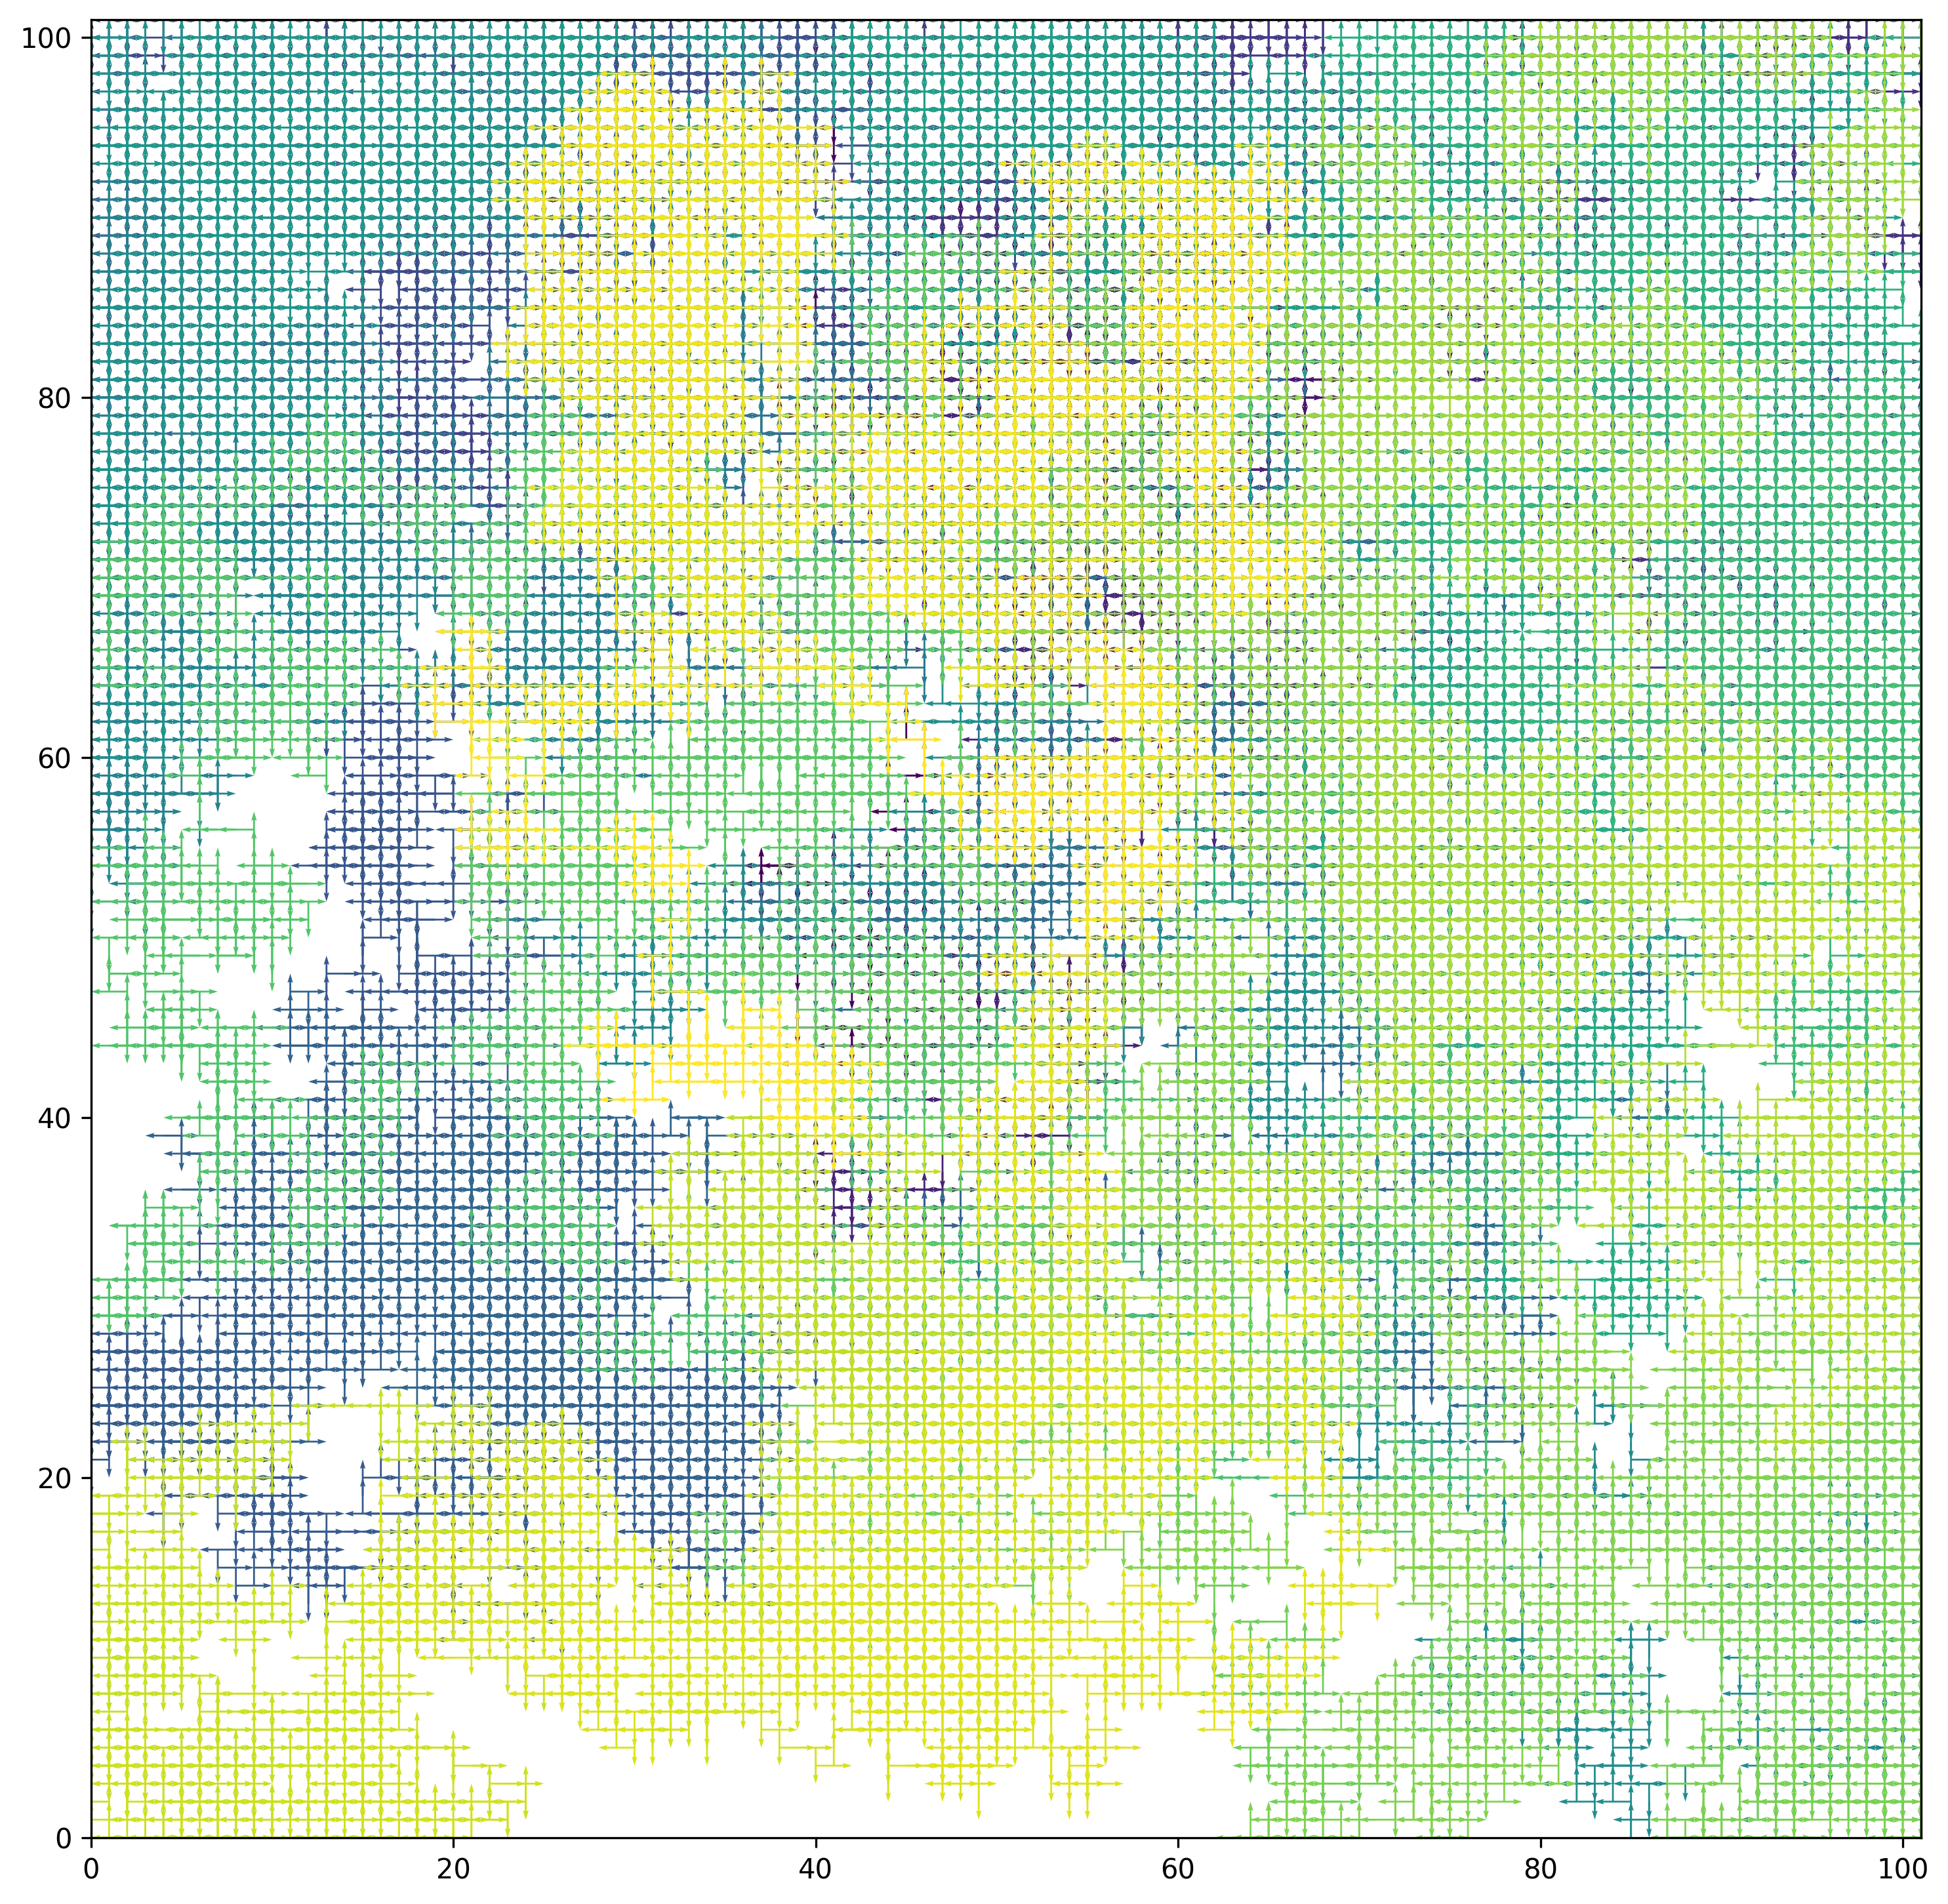

In [55]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

Length = 101

def next_step(x, y, step, L, num_steps):
  if (step > num_steps):
    return None
  dir = random.randint(1,5)
  if (dir == 1 and x<L):
    x += 1
  elif (dir == 2 and x>0):
    x -= 1
  elif (dir == 3 and y<L):
    y += 1
  elif (dir == 4 and y>0):
    y -= 1
  else:
    return next_step(x, y, step, L, num_steps)
  return x,y

def random_walk(x0, y0, L, num_steps):
  coords = [np.array([x0,y0])]
  for i in range(1, num_steps+1):
    x_new,y_new = next_step(x0, y0, i, L, num_steps)
    coords.append(np.array([x_new,y_new]))
    x0, y0 = x_new, y_new
  return coords

def plot_random_walk(coords):
  plt.figure(figsize=(12,12), dpi=300)
  x_coords = [coord[0] for coord in coords]
  y_coords = [coord[1] for coord in coords]
  dx = np.diff(x_coords)
  dy = np.diff(y_coords)
  t = np.arange(len(dx))

  plt.quiver(x_coords[:-1], y_coords[:-1], dx, dy, t, cmap='viridis',
           angles='xy', scale_units='xy', scale=0.5, width=0.001)
  plt.xlim(0, Length)
  plt.ylim(0, Length)
  plt.show()

def main():

  coordis = random_walk(50, 50, 101, 100000)
  plot_random_walk(coordis)

if __name__ == "__main__":
  main()




Run till 100000 only, bacause otherwise the particle traversed the entire grid. Darker lines are positions at old times, yellower lines are at newer times.

# **Question - 3**

**Q.3 (a)**

In [56]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

def integ(x):
  return math.sin(1/(x*(2-x)))*math.sin(1/(x*(2-x)))

def find_integ(N_points):
  points_inside = 0
  for i in range(N_points):
    x = random.uniform(0,2)
    y = random.uniform(0,1)
    if (y <= integ(x)):
      points_inside += 1
  return (points_inside/N_points)*2

N = 10000
I_est = find_integ(N)
print(f"integral with {N} points is: {I_est}")
print(f"error estimate is {math.sqrt(I_est*(2.-I_est)/N)}")


integral with 10000 points is: 1.467
error estimate is 0.008842573154913675


**Q.3 (b)** Run part(a) first

In [57]:
def find_integ_meanv(N_points):
  sumx = 0
  sumx2 = 0
  for i in range(N_points):
    x = random.uniform(0,2)
    sumx += integ(x)
    sumx2 += integ(x)**2
  sumx2 = sumx2/N_points
  sumx = sumx/N_points
  return sumx2, sumx

N = 10000
f2_mean, f_mean = find_integ_meanv(N)
varf = f2_mean - f_mean**2
print(f"variance of integral is {varf}")
print(f"Integral estimate is {f_mean*2}")
print(f"error on the integral is {2*math.sqrt(varf/N)}")


variance of integral is 0.07038311978604272
Integral estimate is 1.4489024672337218
error on the integral is 0.005305963429427034


The error is indeed somewhat smaller compared to the 'hit or miss' method.

# **Question - 4**

In [58]:
import math
import numpy as np
import random

def circle(arrx):
  return np.dot(arrx,arrx)

def find_area_circle(dimension, N_points):
  points_inside = 0
  for i in range(N_points):
    x = np.random.uniform(-1,1,dimension)
    if (circle(x) <= 1):
      points_inside += 1
  return points_inside*math.pow(2,dimension)/N_points

N=100000
print(f"volume of 2-dim unit circle is {find_area_circle(2, N)}")
print(f"volume of 3-dim unit circle is {find_area_circle(3, N)}")
print(f"volume 0f 10-dim unit circle is {find_area_circle(10,N)}")


volume of 2-dim unit circle is 3.13272
volume of 3-dim unit circle is 4.18064
volume 0f 10-dim unit circle is 2.48832


# **Question - 5**

**Q.5 (a)** Using the importance sampling method, the integral of $f(x)$ from a to b is given by

$\int_a^b f(x)\, dx = \langle f(x)/w(x)⟩_w \cdot \int_a^b w(x)\, dx$

$\Rightarrow \int_a^b f(x)\, dx = \sum_i^N f(x_i)/w(x_i) \cdot \int_a^b w(x)\, dx$

where $x_i$ are drawn from a probability distribution

$p(x) = \frac{w(x)}{\int_a^b w(x)\, dx}$

Putting $w(x) = x^{-1/2}$, required probability ditribution is

$p(x) = \frac{w(x)}{\int_a^b w(x)\, dx} = \frac{x^{-1/2}}{\int_0^1 x^{-1/2}\, dx}$

$\int_0^1 x^{-1/2}\, dx = 2x^{1/2}|_0^1 = 2$

$\therefore p(x) = \frac{1}{2\sqrt{x}}$

Let z be a uniform random variable ~$U(0,1)$. We want $p(x)dx = p(z)dz$

$⇒ C_X(x) = z$

$⇒ x = C_X^{-1}(z)$

where $C_X(x)$ is the cumulative probability distribution of x

Now, $C_X(x) = \int_{0}^x \frac{1}{2\sqrt{x}}\, dx = \sqrt{x}|_0^x = \sqrt{x} ⇒C_X^{-1}(z) = z^2$

$⇒ x = z^2$ will have the probability distribution as required.

**Q.5 (b)**

In [59]:
import random
import math

def integrand(x):
  denom = math.exp(x) + 1
  num = math.pow(x,-0.5)
  return num/denom

def give_from_distribution():
  z = random.uniform(0,1)
  return z**2

def monte_carlo(N_points):
  sum  = 0.0
  for i in range(N_points):
    x = give_from_distribution()
    sum += integrand(x)*math.sqrt(x)
  return (sum/N_points)*2

N = 1000000

print(f"Integral estimate is {monte_carlo(N)}")

Integral estimate is 0.8387958476542786


# **Question - 6**

**Q.6 (a)**

In [60]:
import numpy as np

def total_energy(spins, J=1):
    L = spins.shape[0]
    E = 0

    for i in range(L):
        for j in range(L):
            s = spins[i, j]

            # periodic boundary conditions
            right = spins[i, (j+1) % L]
            down  = spins[(i+1) % L, j]

            E += -J * s * (right + down)

    return E

**Q.6 (b)**

In [61]:
import random
import math

def delta_energy(spins, i, j, J=1):
    L = spins.shape[0]
    s = spins[i, j]

    neighbors = (
        spins[(i+1)%L, j] +
        spins[(i-1)%L, j] +
        spins[i, (j+1)%L] +
        spins[i, (j-1)%L]
    )

    return 2 * J * s * neighbors

def ising_simulation(L=20, T=1, steps=1000000):
    spins = np.random.choice([-1, 1], size=(L, L))

    magnetization = []

    for step in range(steps):
        # pick random spin
        i = random.randrange(L)
        j = random.randrange(L)

        dE = delta_energy(spins, i, j)

        # Metropolis rule
        if dE <= 0 or random.random() < math.exp(-dE / T):
            spins[i, j] *= -1

        # record magnetization
        M = np.sum(spins)
        magnetization.append(M)

    return spins, magnetization

**Q.6 (c)**

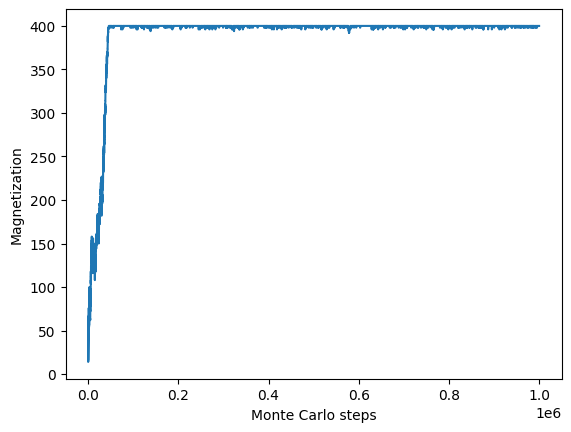

In [62]:
import matplotlib.pyplot as plt

spins_1, M_1 = ising_simulation(T=1, steps=1000000)

plt.plot(M_1)
plt.xlabel("Monte Carlo steps")
plt.ylabel("Magnetization")
plt.show()

**Q.6 (d)** We see that the magnitization that develops is sometimes negatve and sometimes positive. This is because both the +1 and -1 spins are equaly likely for all cells. The system has the same minimum energy if all cells are aligned, irrespective of the sign. Therefore, under equilibrium, the system can have net +ve magnetization or net -ve magnetization.

**Q.6 (e)**

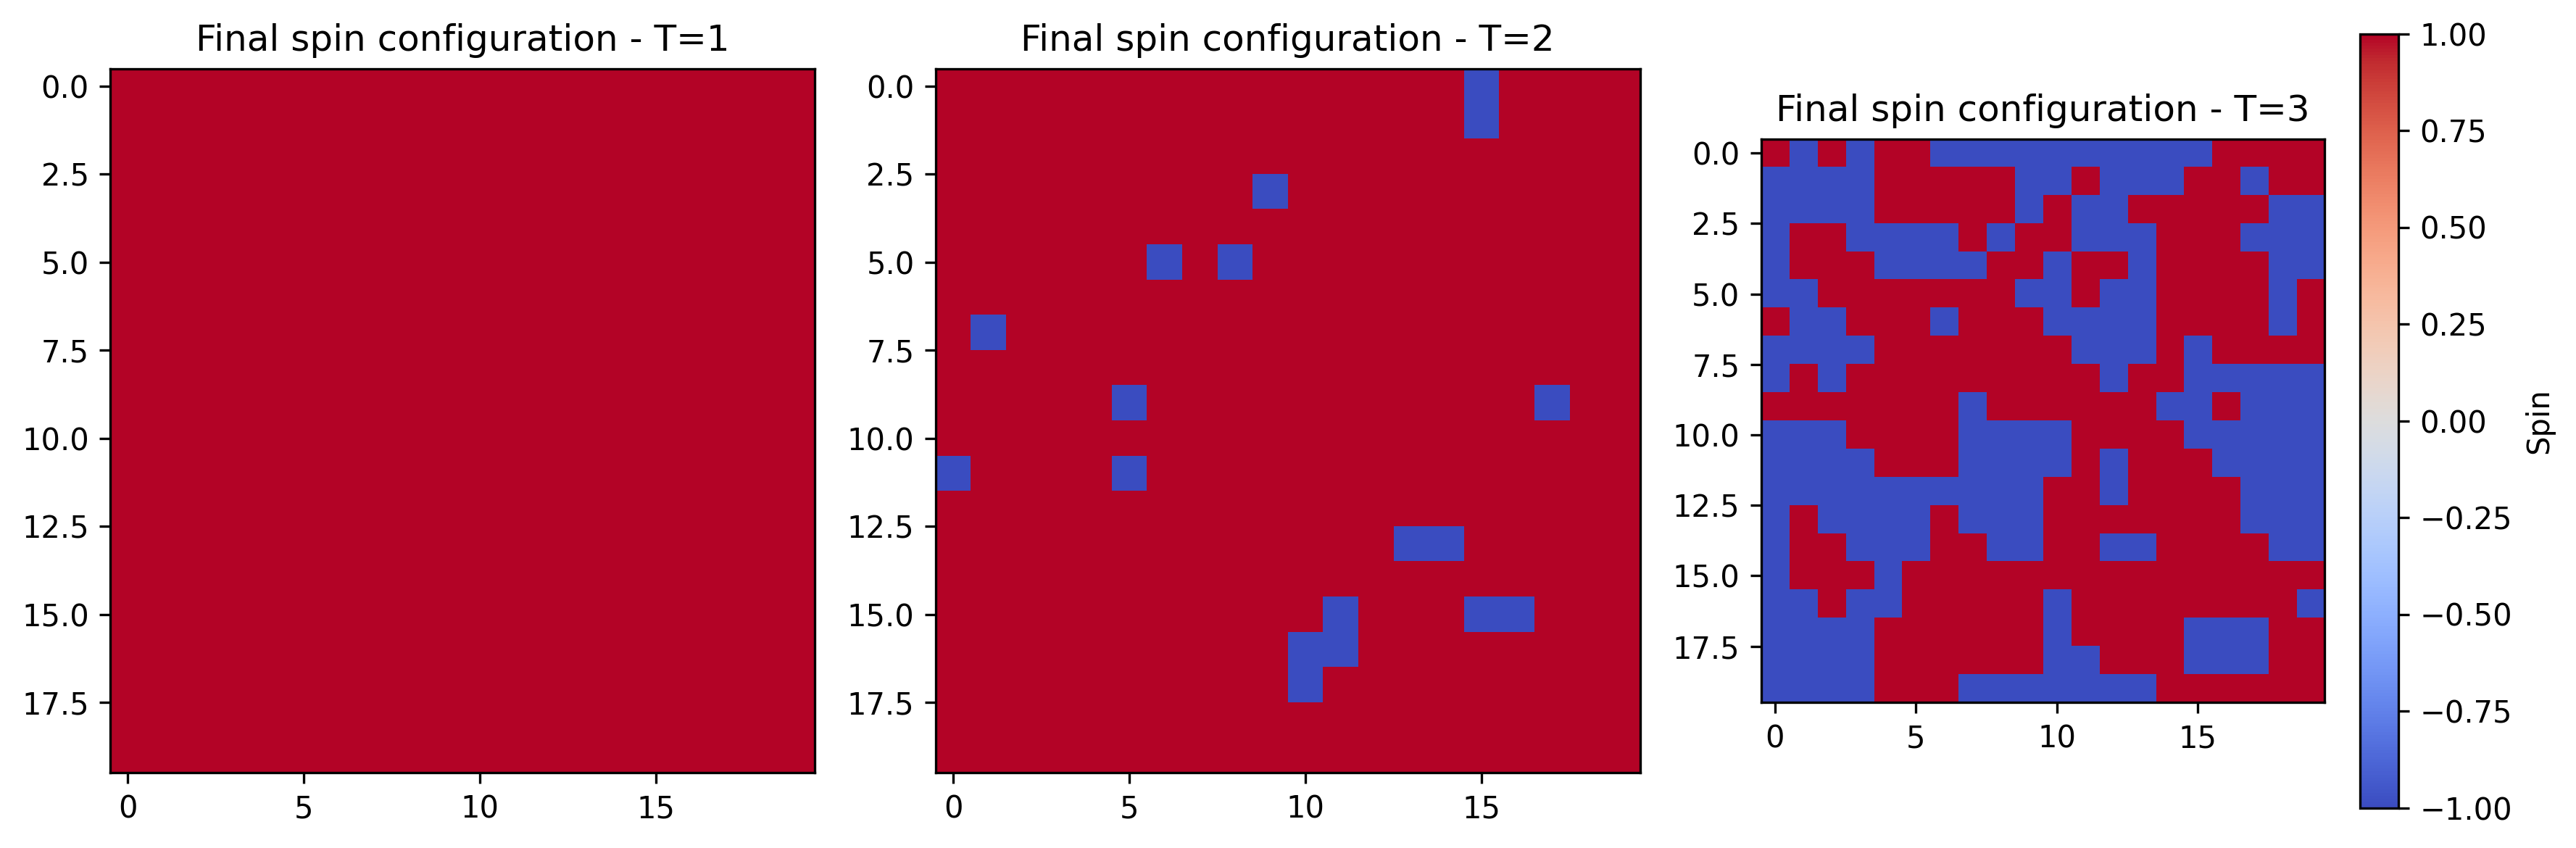

In [63]:
import matplotlib.pyplot as plt

spins_1, M_1 = ising_simulation(T=1, steps=1000000)
spins_2, M_2 = ising_simulation(T=2, steps=1000000)
spins_3, M_3 = ising_simulation(T=3, steps=1000000)

plt.figure(figsize=(12,4), dpi=300)
plt.subplot(1,3,1)
plt.imshow(spins_1, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Final spin configuration - T=1")

plt.subplot(1,3,2)
plt.imshow(spins_2, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Final spin configuration - T=2")

plt.subplot(1,3,3)
plt.imshow(spins_3, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label="Spin")
plt.title("Final spin configuration - T=3")
plt.tight_layout()
plt.show()


We observe that for T=1, almost the entire grid has single spin state - either +1 or -1. But as T increases to 2, some cells are not aligned with others. For T=3, the system does not exhibit large aligned domains at all. Thermal energy dominates the interaction energy of the system hence spins are oriented randomly.

# **Question - 7**

**Q.7 (a)**

In [64]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 - np.cos(4*np.pi*x)

def simulated_annealing(f, x0, T0, tau, steps):
    x = x0
    xs = []

    for t in range(steps):
        T = T0 * np.exp(-t / tau)

        x_new = x + np.random.normal(0, 1)

        dE = f(x_new) - f(x)

        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            x = x_new

        xs.append(x)

    return x, xs

Final x: 0.0018802142483041184


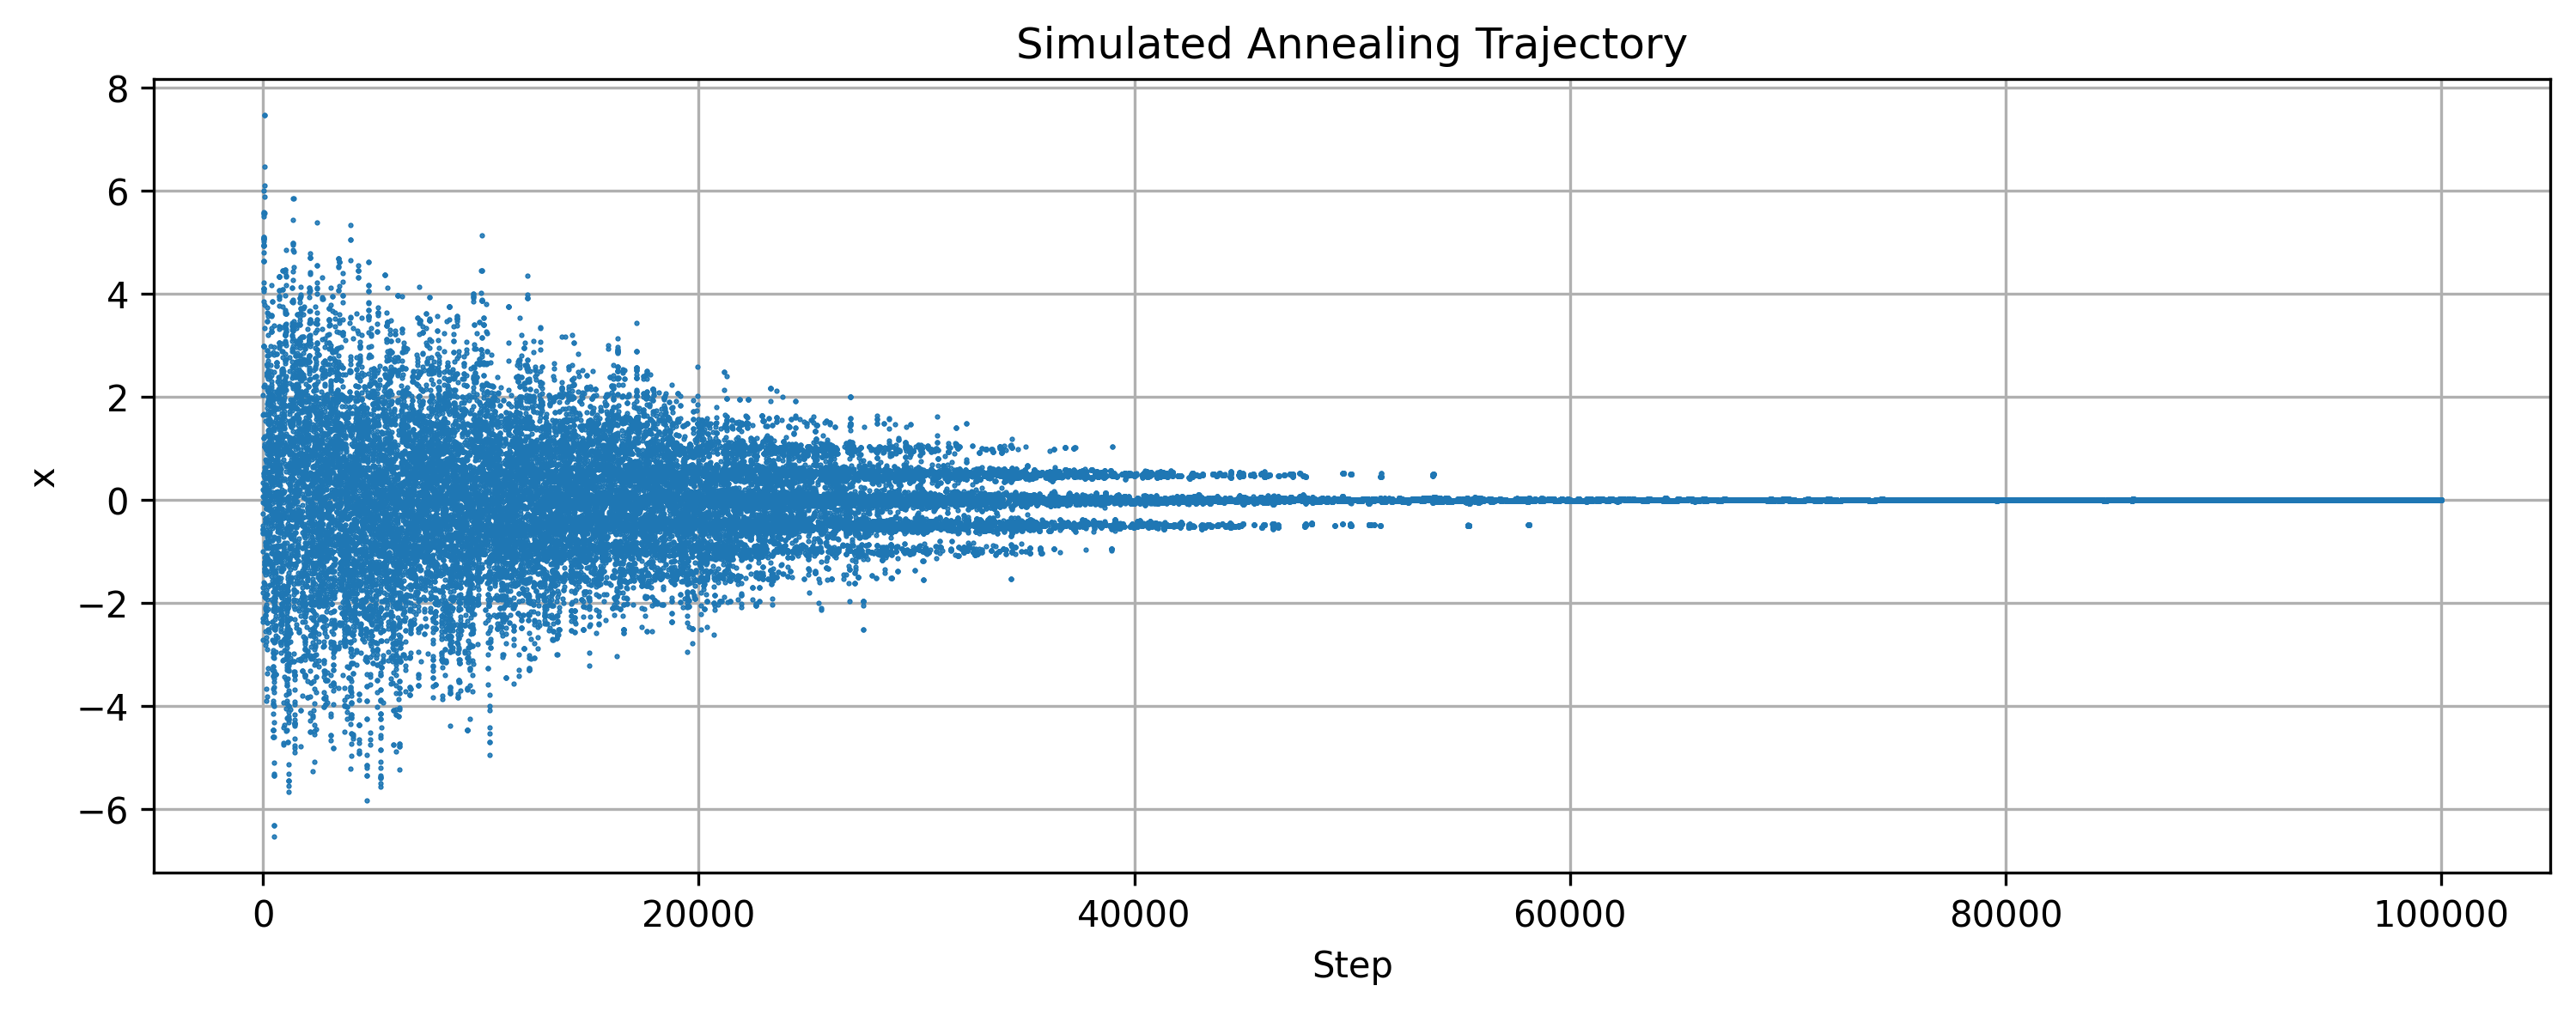

In [65]:
x_final, xs = simulated_annealing(
    f,
    x0=2,
    T0=10,
    tau=10000,
    steps=100000
)

print("Final x:", x_final)

plt.figure(figsize=(12,4), dpi=300)
plt.plot(xs, ".", markersize=1)
plt.xlabel("Step")
plt.ylabel("x")
plt.grid(which='both')
plt.title("Simulated Annealing Trajectory")
plt.show()

**Q.7 (b)**

Final x (f2): 2.1626573816179904


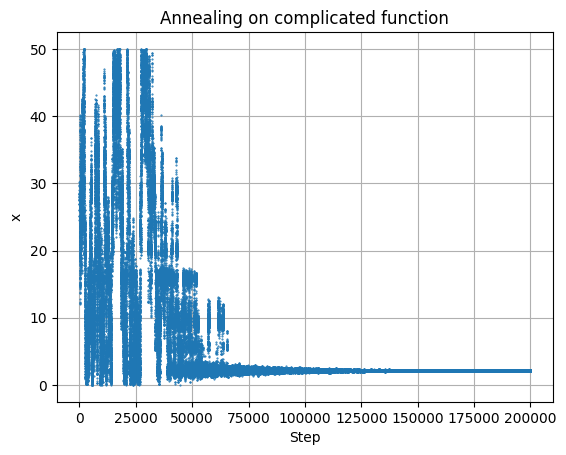

In [66]:
def f2(x):
    return np.cos(x) + np.cos(np.sqrt(2)*x) + np.cos(np.sqrt(3)*x)

def simulated_annealing_bounded(f, x0, T0, tau, steps):
    x = x0
    xs = []

    for t in range(steps):
        T = T0 * np.exp(-t / tau)

        x_new = x + np.random.normal(0, 1)

        # enforcing bounds
        if x_new < 0 or x_new > 50:
            xs.append(x)
            continue

        dE = f(x_new) - f(x)

        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            x = x_new

        xs.append(x)

    return x, xs

x_final2, xs2 = simulated_annealing_bounded(
    f2,
    x0=25,
    T0=10,
    tau=20000,
    steps=200000
)

print("Final x (f2):", x_final2)

plt.plot(xs2, ".", markersize=1)
plt.xlabel("Step")
plt.ylabel("x")
plt.title("Annealing on complicated function")
plt.grid(which='both')
plt.show()

# **Question - 8**

**Q.8 (a)** The variables $\theta$ and $\phi$ lie in ranges as follows

$\theta \in [0,\pi],\ \phi \in [0,2\pi]$

Now, $\int_0^\pi p(\theta)d\theta = \frac{1}{2}\int_0^\pi \sin \theta d\theta = -\frac{1}{2}\cos\theta |_0^\pi = 1$

Also, $\int_0^{2\pi} p(\phi)d\phi = \frac{1}{2\pi}\int_0^{2\pi} \phi\, d\phi =  1$

Therefore, both distributions are normalised.

**Q.8 (b)** Let $z$ be a uniform variate in $(0,1)$.

As done in Q.5 part (b), if we define

$\theta ' = C_{\theta}^{-1}(z)$ and $\phi ' = C_{\phi}^{-1}(z)$ then $\theta '$ and $\phi '$ will have the distributions we want.

$C_{\theta}(x) = \int_0^xp(\theta)\, d\theta = \frac{1}{2}\int_0^x \sin \theta d\theta = -\frac{1}{2}\cos\theta |_0^x = \frac{1}{2}[1-\cos x]$

$C_{\phi}(x) = \int_0^xp(\phi)\, d\phi = \frac{1}{2\pi}\int_0^x d\phi = \frac{x}{2\pi}$

therefore $y=C_{\theta}(x) = \frac{1}{2}[1-\cos x] ⇒ x = \cos^{-1}(1-2y)$

and $y=C_{\phi}(x) = \frac{x}{2\pi}⇒ x = 2\pi y$

therefore if z is $U(0,1)$ and we define $\theta = \cos^{-1}(1-2z)$ and $\phi = 2\pi z$ then they will have distributions as required.

**Q.8 (c)**

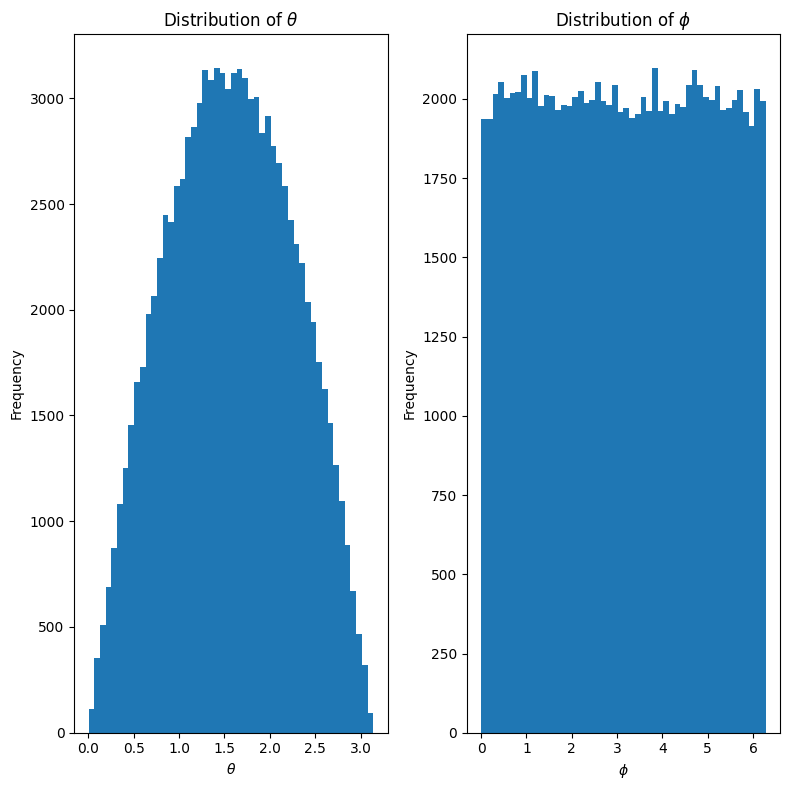

In [67]:
import numpy as np
N = 100000

u = np.random.rand(N)
v = np.random.rand(N)

theta = np.arccos(1 - 2*u)
phi = 2 * np.pi * v

plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.hist(theta, bins=50)
plt.xlabel(r"$\theta$")
plt.ylabel("Frequency")
plt.title(r"Distribution of $\theta$")

plt.subplot(1,2,2)
plt.hist(phi, bins=50)
plt.xlabel(r"$\phi$")
plt.ylabel("Frequency")
plt.title(r"Distribution of $\phi$")
plt.tight_layout()
plt.show()